,mesorregiao,ano_real,soma_dec28_ano1,n_municipios,media_historica_mesorregiao,anomalia,anomalia_pct,variavel_clima,coluna_usada
0,Centro Ocidental Paranaense,2018,89.2350,25,84.8426,4.3924,5.1772,PW,PW_dec34_ano1
1,Centro Ocidental Paranaense,2019,52.3070,25,84.8426,-32.5356,-38.3482,PW,PW_dec34_ano1
2,Centro Ocidental Paranaense,2020,81.8720,25,84.8426,-2.9706,-3.5013,PW,PW_dec34_ano1
3,Centro Ocidental Paranaense,2021,85.3220,25,84.8426,0.4794,0.5651,PW,PW_dec34_ano1
4,Centro Ocidental Paranaense,2022,51.4430,25,84.8426,-33.3996,-39.3665,PW,PW_dec34_ano1


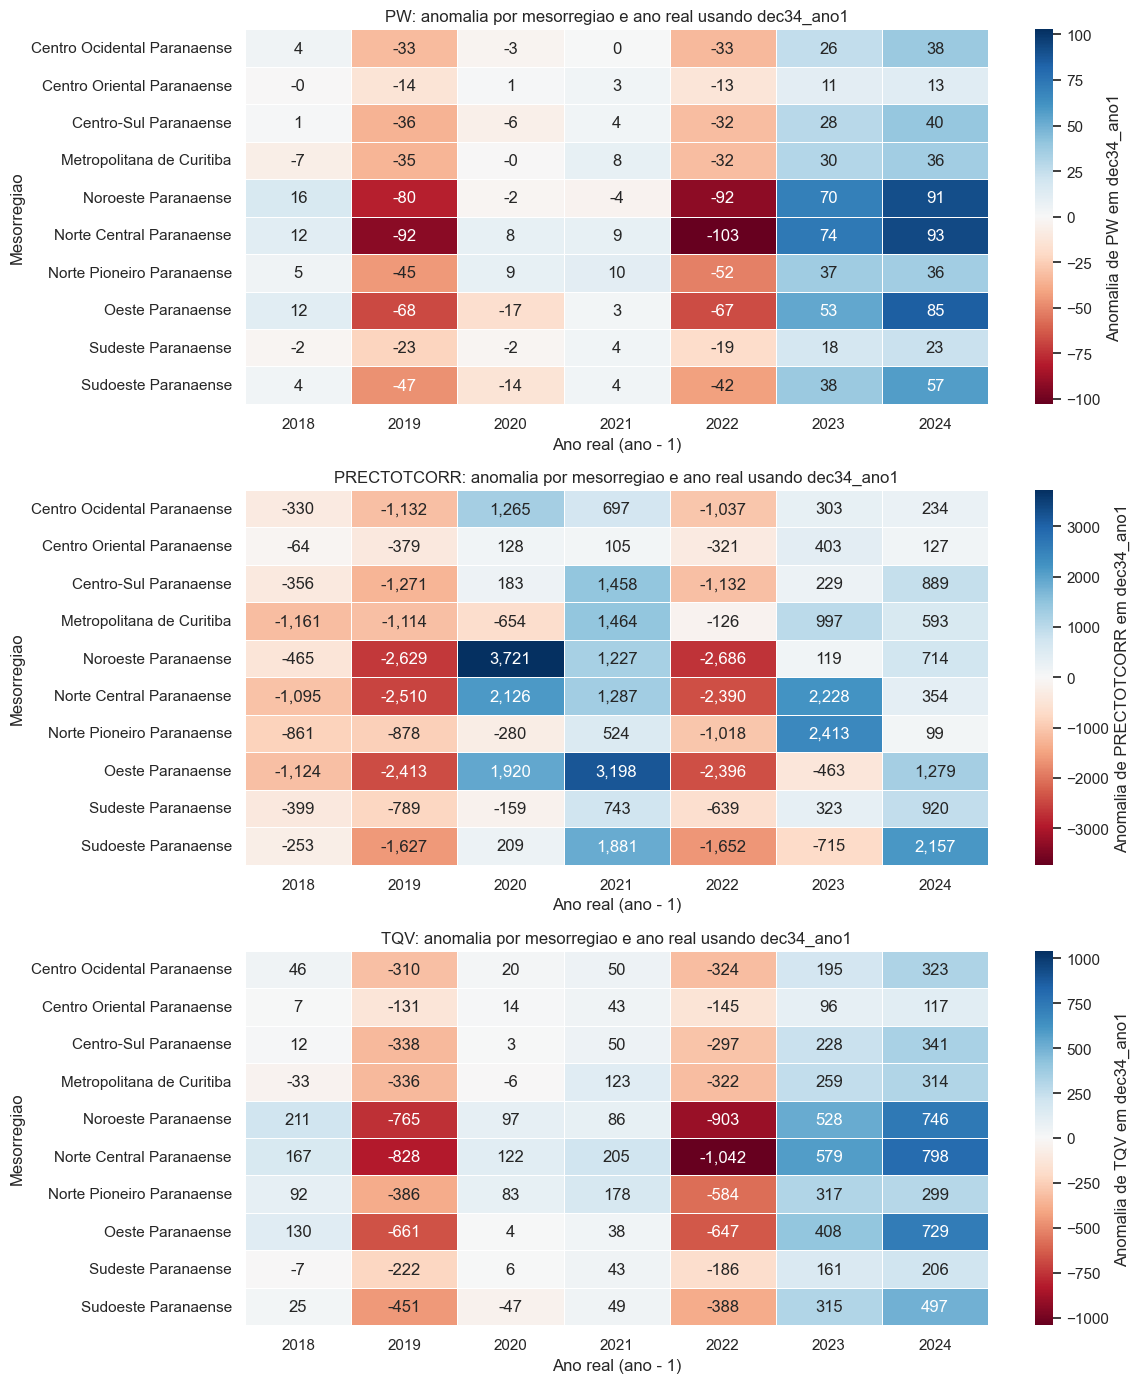

In [20]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', '{:,.4f}'.format)
sns.set_theme(style='whitegrid', context='notebook')

# Fonte unica de dados
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_FINAL = PROJECT_ROOT / 'data' / 'processed' / 'dataset_final.parquet'
VARIAVEIS_CLIMA = ['PW', 'PRECTOTCORR','TQV']
COLUNA_DECENDIO = 'dec34_ano1'

dataset = pd.read_parquet(DATA_FINAL).copy()
dataset['ano'] = pd.to_numeric(dataset['ano'], errors='coerce').astype('Int64')

anomalias = []
for var in VARIAVEIS_CLIMA:
    col = f'{var}_{COLUNA_DECENDIO}'
    if col not in dataset.columns:
        raise ValueError(f'Coluna nao encontrada: {col}')

    dados = dataset[['ano', 'mesorregiao', 'municipio', col]].copy()
    dados[col] = pd.to_numeric(dados[col], errors='coerce')
    dados['ano_real'] = dados['ano'] # dec28_ano1 pertence ao ano anterior ao ano/safra

    agregado = (
        dados
        .groupby(['mesorregiao', 'ano_real'], as_index=False)
        .agg(
            soma_dec28_ano1=(col, 'sum'),
            n_municipios=('municipio', 'nunique')
        )
    )
    agregado['media_historica_mesorregiao'] = agregado.groupby('mesorregiao')['soma_dec28_ano1'].transform('mean')
    agregado['anomalia'] = agregado['soma_dec28_ano1'] - agregado['media_historica_mesorregiao']
    agregado['anomalia_pct'] = np.where(
        agregado['media_historica_mesorregiao'].ne(0),
        agregado['anomalia'] / agregado['media_historica_mesorregiao'] * 100,
        np.nan
    )
    agregado['variavel_clima'] = var
    agregado['coluna_usada'] = col
    anomalias.append(agregado)

anomalias_dec28 = pd.concat(anomalias, ignore_index=True)

display(anomalias_dec28.head())

fig, axes = plt.subplots(len(VARIAVEIS_CLIMA), 1, figsize=(12, 14))
if len(VARIAVEIS_CLIMA) == 1:
    axes = [axes]

for ax, var in zip(axes, VARIAVEIS_CLIMA):
    dados = anomalias_dec28.loc[anomalias_dec28['variavel_clima'].eq(var)].copy()
    matriz = dados.pivot(index='mesorregiao', columns='ano_real', values='anomalia').sort_index()
    vmax = np.nanmax(np.abs(matriz.to_numpy()))

    sns.heatmap(
        matriz,
        ax=ax,
        cmap='RdBu',
        center=0,
        vmin=-vmax,
        vmax=vmax,
        annot=True,
        fmt=',.0f',
        linewidths=.5,
        linecolor='white',
        cbar_kws={'label': f'Anomalia de {var} em {COLUNA_DECENDIO}'}
    )
    ax.set_title(f'{var}: anomalia por mesorregiao e ano real usando {COLUNA_DECENDIO}')
    ax.set_xlabel('Ano real (ano - 1)')
    ax.set_ylabel('Mesorregiao')

plt.tight_layout()
plt.show()


,variavel_clima,ano,soma_anual,media_municipal,n_municipios
0,PW,2018,"17,786.5945",44.5779,399
1,PW,2019,"18,309.6884",45.8889,399
2,PW,2020,"18,626.9058",46.6840,399
3,PW,2021,"17,009.9753",42.6315,399
4,PW,2022,"15,980.9155",40.0524,399
5,PW,2023,"17,923.6931",44.9215,399
6,PW,2024,"20,411.3664",51.1563,399
7,PRECTOTCORR,2018,"395,541.6400",991.3324,399
8,PRECTOTCORR,2019,"256,747.8200",643.4782,399
9,PRECTOTCORR,2020,"257,927.2600",646.4342,399


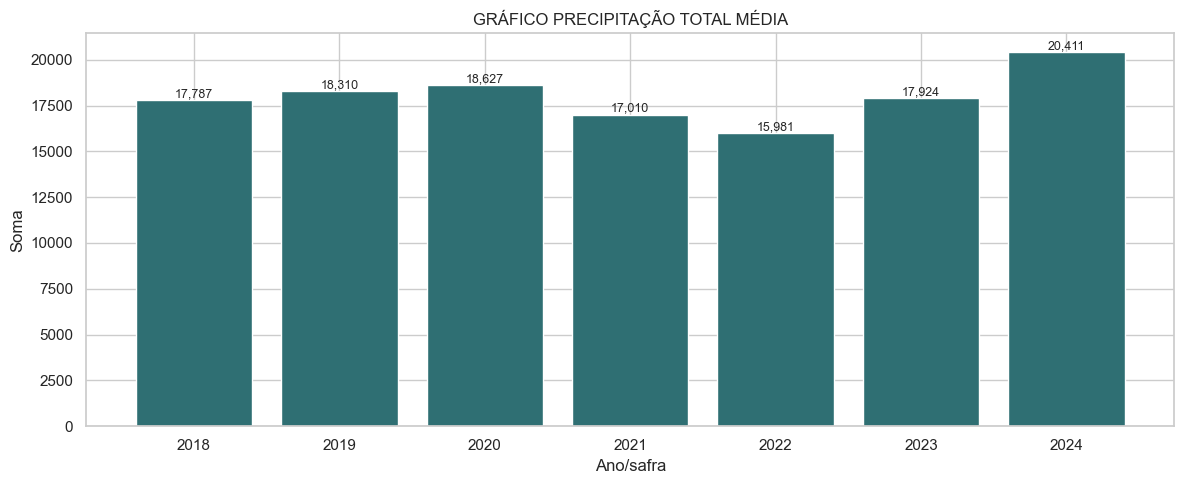

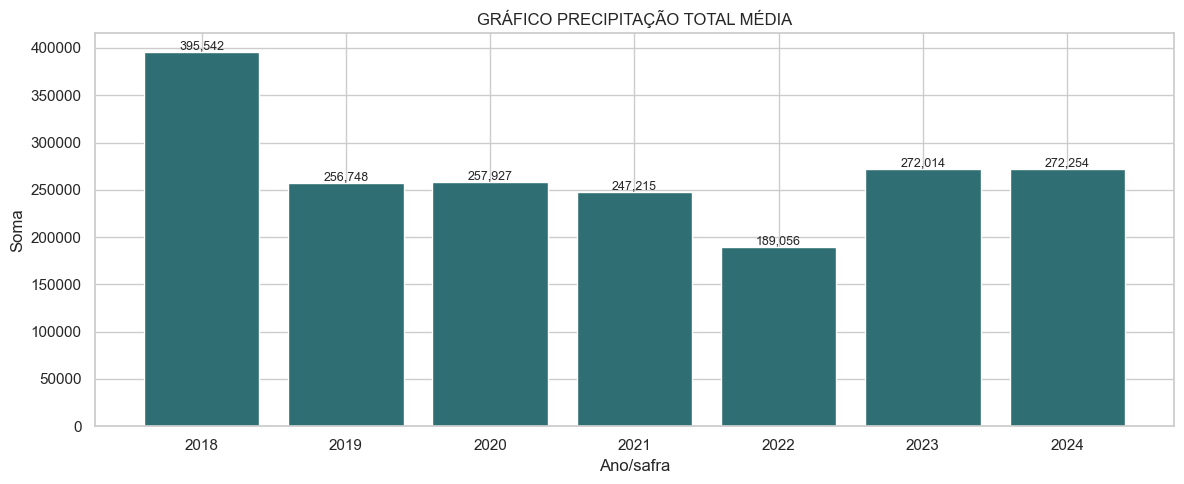

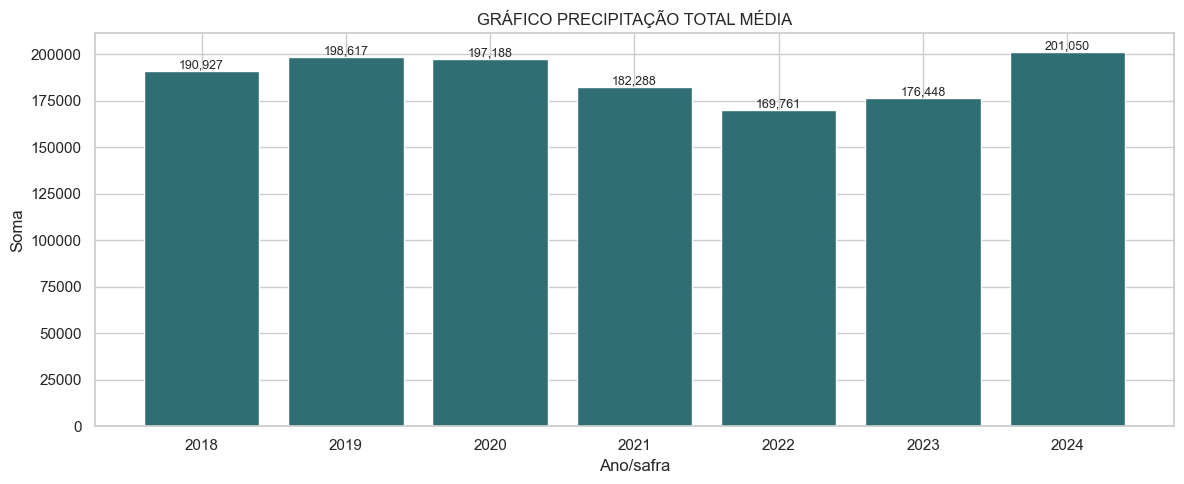

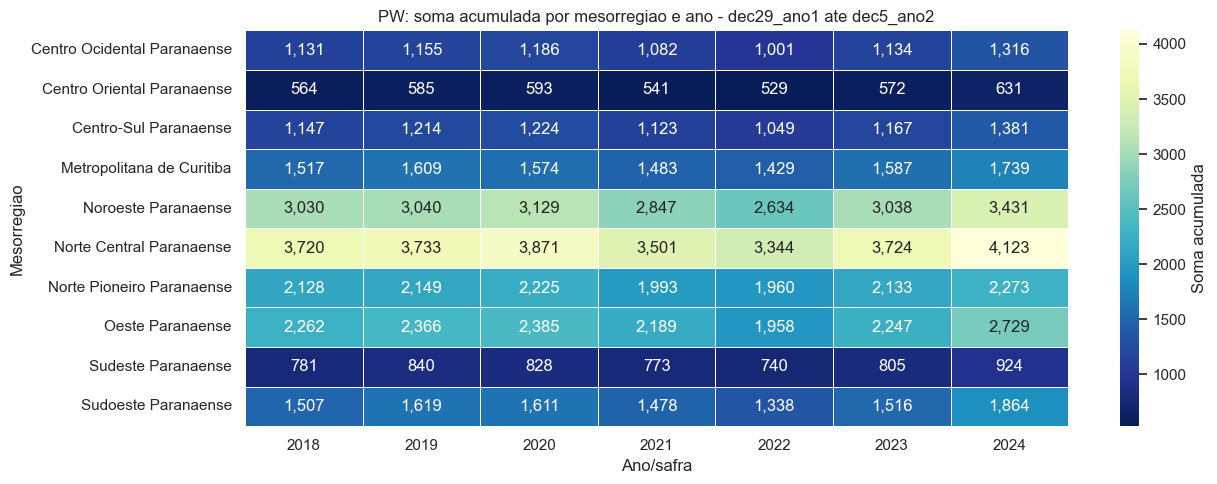

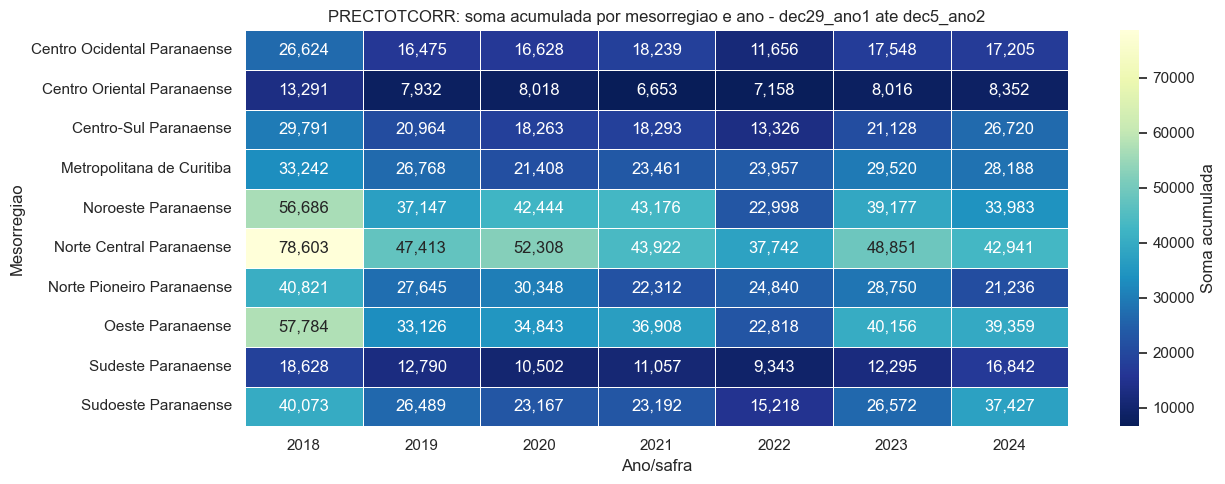

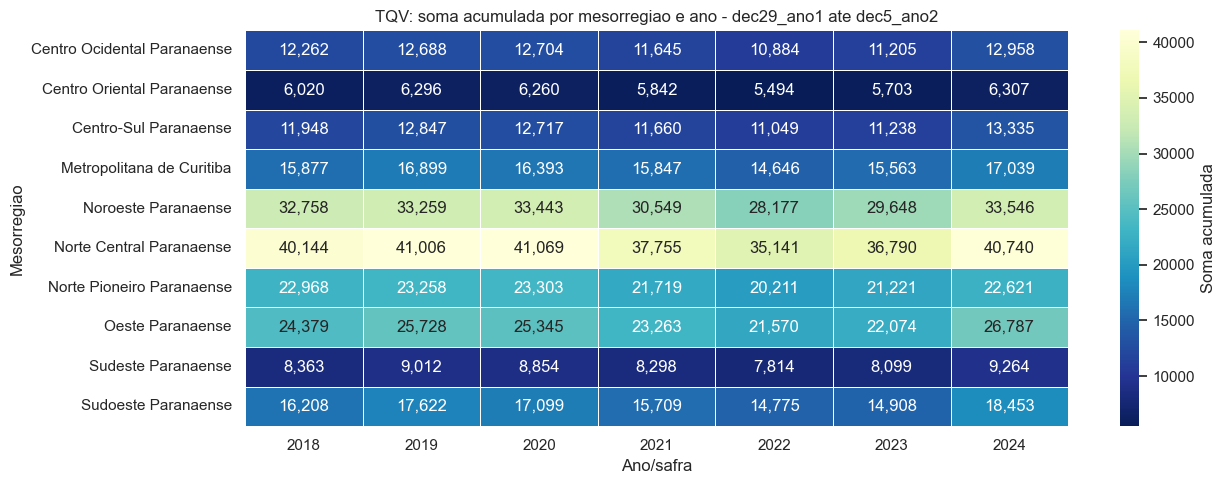

In [22]:
# Agregacao da janela dec29_ano1 ate dec5_ano2
# Para visualizacao anual, a janela e associada ao ano/safra da coluna `ano`.
# Internamente, dec*_ano1 pertence a ano-1 e dec*_ano2 pertence ao proprio ano.

JANELA_COLUNAS = {
    'ano1': list(range(29, 37)),
    'ano2': list(range(1, 6)),
}

agregados_janela = []
heatmaps_janela = []
colunas_somadas_por_variavel = {}

for var in VARIAVEIS_CLIMA:
    cols = []
    for dec in JANELA_COLUNAS['ano1']:
        col = f'{var}_dec{dec}_ano1'
        if col in dataset.columns:
            cols.append(col)
    for dec in JANELA_COLUNAS['ano2']:
        col = f'{var}_dec{dec}_ano2'
        if col in dataset.columns:
            cols.append(col)

    if not cols:
        raise ValueError(f'Nenhuma coluna encontrada para {var} na janela dec29_ano1 ate dec5_ano2')

    colunas_somadas_por_variavel[var] = cols
    dados = dataset[['ano', 'mesorregiao', 'municipio'] + cols].copy()
    for col in cols:
        dados[col] = pd.to_numeric(dados[col], errors='coerce')

    dados[f'{var}_soma_janela'] = dados[cols].sum(axis=1, min_count=1)

    agregado_anual = (
        dados
        .groupby('ano', as_index=False)
        .agg(
            soma_anual=(f'{var}_soma_janela', 'sum'),
            media_municipal=(f'{var}_soma_janela', 'mean'),
            n_municipios=('municipio', 'nunique')
        )
        .sort_values('ano')
    )
    agregado_anual['variavel_clima'] = var
    agregado_anual['colunas_somadas'] = ', '.join(cols)
    agregados_janela.append(agregado_anual)

    agregado_mesorregiao = (
        dados
        .groupby(['mesorregiao', 'ano'], as_index=False)
        .agg(
            soma_acumulada=(f'{var}_soma_janela', 'sum'),
            n_municipios=('municipio', 'nunique')
        )
        .sort_values(['mesorregiao', 'ano'])
    )
    agregado_mesorregiao['variavel_clima'] = var
    heatmaps_janela.append(agregado_mesorregiao)

agregado_dec29_dec5 = pd.concat(agregados_janela, ignore_index=True)
heatmap_dec29_dec5 = pd.concat(heatmaps_janela, ignore_index=True)

display(agregado_dec29_dec5[['variavel_clima', 'ano', 'soma_anual', 'media_municipal', 'n_municipios']])

# Graficos de barras separados por variavel
for var in VARIAVEIS_CLIMA:
    dados_plot = agregado_dec29_dec5.loc[agregado_dec29_dec5['variavel_clima'].eq(var)].copy()

    plt.figure(figsize=(12, 5))
    bars = plt.bar(
        dados_plot['ano'].astype(str),
        dados_plot['soma_anual'],
        color='#2f6f73',
        edgecolor='white'
    )

    for bar, valor in zip(bars, dados_plot['soma_anual']):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{valor:,.0f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

    plt.title(f'GRÁFICO PRECIPITAÇÃO TOTAL MÉDIA')
    plt.xlabel('Ano/safra')
    plt.ylabel('Soma')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Heatmaps separados por variavel, com mesorregioes em ordem alfabetica
for var in VARIAVEIS_CLIMA:
    dados_heatmap = heatmap_dec29_dec5.loc[heatmap_dec29_dec5['variavel_clima'].eq(var)].copy()
    matriz = (
        dados_heatmap
        .pivot(index='mesorregiao', columns='ano', values='soma_acumulada')
        .sort_index()
    )

    plt.figure(figsize=(13, max(5, 0.35 * len(matriz))))
    sns.heatmap(
        matriz,
        cmap='YlGnBu_r',
        annot=True,
        fmt=',.0f',
        linewidths=0.4,
        linecolor='white',
        cbar_kws={'label': 'Soma acumulada'}
    )
    plt.title(f'{var}: soma acumulada por mesorregiao e ano - dec29_ano1 ate dec5_ano2')
    plt.xlabel('Ano/safra')
    plt.ylabel('Mesorregiao')
    plt.tight_layout()
    plt.show()
